In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('customer.csv')

In [3]:
df.sample(10)

,age,gender,review,education,purchased
39,76,Male,Poor,PG,No
6,18,Male,Good,School,No
11,74,Male,Good,UG,Yes
46,64,Female,Poor,PG,No
33,89,Female,Good,PG,Yes
34,86,Male,Average,School,No
42,30,Female,Good,PG,Yes
19,97,Male,Poor,PG,Yes
26,53,Female,Poor,PG,No
30,73,Male,Average,UG,No


15
15.0


<Axes: xlabel='age', ylabel='Density'>

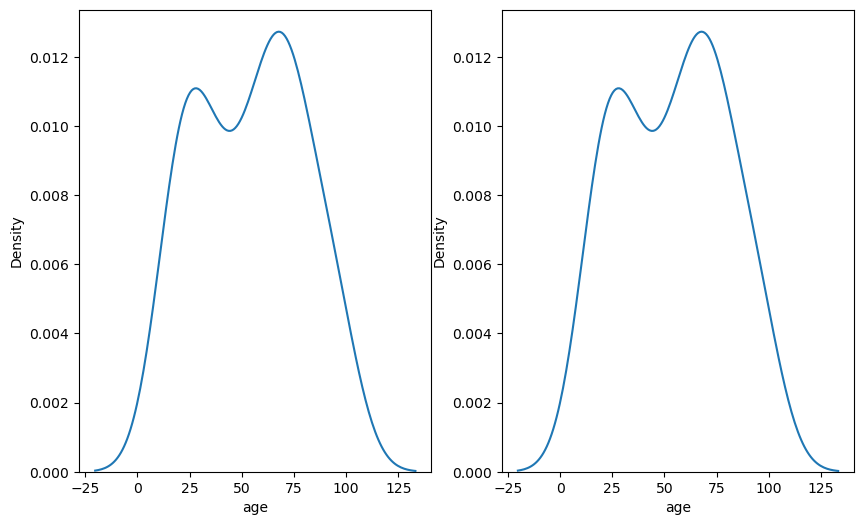

In [4]:
fig , ax = plt.subplots(1,2,figsize=(10,6))
sns.kdeplot(x='age',data=df,ax=ax[0])
mean_age=df['age'].mean()

print(df['age'].min())

df['age']= np.where(
    df['age']<0,
    mean_age,
    df['age']
)
print(df['age'].min())

sns.kdeplot(x='age',data=df,ax=ax[1])

In [5]:
x=df.drop(columns=['purchased'])
y=df['purchased']

In [6]:
from sklearn.model_selection import train_test_split;
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [7]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [8]:
scalar=MinMaxScaler()
one=OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])

In [9]:
x_train.sample(10)

,age,gender,review,education
16,59.0,Male,Poor,UG
38,45.0,Female,Good,School
41,23.0,Male,Good,PG
33,89.0,Female,Good,PG
42,30.0,Female,Good,PG
2,70.0,Female,Good,PG
10,98.0,Female,Good,UG
28,48.0,Male,Poor,School
5,31.0,Female,Average,School
23,96.0,Female,Good,School


In [10]:
numerical_cols=['age']
order_category=['review','education']
cat=['gender']

In [11]:
x_train[order_category]=one.fit_transform(x_train[order_category])

In [12]:
x_test[order_category]=one.fit_transform(x_test[order_category])

In [15]:
le=LabelEncoder()
for col in cat:
    x_train[col] = le.fit_transform(x_train[col])

In [16]:
for col in cat:
    x_test[col] = le.fit_transform(x_test[col])

In [24]:
y_train=le.fit_transform(y_train)
y_test  = y_test.squeeze()
y_test=le.transform(y_test)

ValueError: invalid literal for int() with base 10: 'No'